# Pytorch Implementation of ResNet for Sign Language Recognition
This notebook replicates the ResNet architecture defined in `ML_Note12_1.ipynb` using PyTorch.

In [17]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
torch.manual_seed(1)
np.random.seed(1)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1. Data Loading and Preprocessing
Load the SIGNS dataset and convert it to PyTorch Tensors (N, C, H, W).

In [18]:
def load_dataset():
    train_dataset = h5py.File('datasets/train_signs.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # (1080, 64, 64, 3)
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # (1080,)

    test_dataset = h5py.File('datasets/test_signs.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # (120, 64, 64, 3)
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # (120,)

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    # PyTorch CrossEntropyLoss expects class indices, so we squeeze the labels to shape (N,)
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

class SignsDataset(Dataset):
    def __init__(self, X, Y):
        # X shape: (N, 64, 64, 3) -> Need (N, 3, 64, 64)
        self.X = torch.FloatTensor(X.transpose(0, 3, 1, 2)) / 255.0
        # Y shape: (1, N) -> Need (N,)
        self.Y = torch.LongTensor(Y.squeeze())
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Load data
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

# Create Dataset and DataLoader
batch_size = 16

train_dataset = SignsDataset(X_train_orig, Y_train_orig)
test_dataset = SignsDataset(X_test_orig, Y_test_orig)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Input shape: {train_dataset[0][0].shape}")

Train set size: 1080
Test set size: 120
Input shape: torch.Size([3, 64, 64])


### 2. Model Definition (ResNet Architecture)
Replicating the exact structure from `ML_Note12_1.ipynb`:

**ResBlock:**
- Conv(in=3, out=6, k=4, s=1, same_padding) -> BN
- Conv(in=6, out=16, k=5, s=1, same_padding) -> BN
- Conv(in=16, out=64, k=6, s=1, same_padding) -> BN
- **Shortcut Connection**: Input -> Projection Conv(k=1) -> Add to BN output
- ReLU
- AvgPool(k=2, s=2)

**Heads:**
- FC(22) -> BN -> ReLU
- FC(6) -> Softmax

**Padding Details:**
Replicating `CNN_v3.py` asymmetric padding logic for `same_padding=True`:
- If `total_padding` is odd, `top/left` gets `+1` padding compared to `bottom/right`.
- `k=4` (pad=3): (2, 1, 2, 1) -> (Left, Right, Top, Bottom)
- `k=5` (pad=4): (2, 2, 2, 2)
- `k=6` (pad=5): (3, 2, 3, 2)

In [19]:
class ResNetSign(nn.Module):
    def __init__(self):
        super(ResNetSign, self).__init__()
        
        # ------------------ ResBlock ------------------
        # Layer 1: Conv 3->6, k=4, s=1, same_padding
        # Padding: (Left, Right, Top, Bottom) = (2, 1, 2, 1)
        self.pad1 = nn.ZeroPad2d((2, 1, 2, 1)) 
        self.conv1 = nn.Conv2d(3, 6, kernel_size=4, stride=1)
        self.bn1 = nn.BatchNorm2d(6, momentum=0.1) # momentum=0.1 corresponds to alpha=0.1 in Keras/custom
        
        # Layer 2: Conv 6->16, k=5, s=1, same_padding
        # Padding: (2, 2, 2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm2d(16, momentum=0.1)
        
        # Layer 3: Conv 16->64, k=6, s=1, same_padding
        # Padding: (3, 2, 3, 2)
        self.pad3 = nn.ZeroPad2d((3, 2, 3, 2))
        self.conv3 = nn.Conv2d(16, 64, kernel_size=6, stride=1)
        self.bn3 = nn.BatchNorm2d(64, momentum=0.1)
        
        # Shortcut Projection: 3->64, k=1, s=1
        self.proj = nn.Conv2d(3, 64, kernel_size=1, stride=1)
        
        # Activation and Pooling after addition
        self.relu = nn.ReLU()
        self.avgpool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # ------------------ FC Head ------------------
        # Output size after AvgPool: 64 x 32 x 32
        self.flatten_dim = 64 * 32 * 32
        
        self.fc1 = nn.Linear(self.flatten_dim, 22)
        self.bn_fc = nn.BatchNorm1d(22, momentum=0.1)
        # self.relu_fc = nn.ReLU() # Reused
        
        self.fc2 = nn.Linear(22, 6)
        
    def forward(self, x):
        identity = x
        
        # --- ResBlock Body ---
        # [Conv, BN, Conv, BN, Conv, BN]
        
        # Layer 1
        out = self.pad1(x)
        out = self.conv1(out)
        out = self.bn1(out)
        
        # Layer 2
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Layer 3
        out = self.pad3(out)
        out = self.conv3(out)
        out = self.bn3(out)
        
        # --- Residual Connection ---
        # The connected_layer was the last BN. Addition happens here.
        # We need to project identity to match channels (3 -> 64)
        identity_proj = self.proj(identity)
        out = out + identity_proj
        
        # --- Post ResBlock ---
        out = self.relu(out)
        out = self.avgpool(out)
        
        # --- FC Head ---
        out = out.view(out.size(0), -1) # Flatten
        
        out = self.fc1(out)
        out = self.bn_fc(out)
        out = self.relu(out)
        
        out = self.fc2(out)
        # Softmax is handled by CrossEntropyLoss
        return out

model = ResNetSign().to(device)
print(model)

ResNetSign(
  (pad1): ZeroPad2d((2, 1, 2, 1))
  (conv1): Conv2d(3, 6, kernel_size=(4, 4), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pad3): ZeroPad2d((3, 2, 3, 2))
  (conv3): Conv2d(16, 64, kernel_size=(6, 6), stride=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (proj): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU()
  (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=65536, out_features=22, bias=True)
  (bn_fc): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=22, out_features=6, bias=True)
)


### 3. Training Loop

In [20]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    cost_history = []
    
    print(f"Training for {epochs} epochs...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward + Backward + Optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # Log batch loss occasionally
            if i % 13 == 0 and epoch % 5 ==0:  # Roughly 5 logs per epoch for 68 batches
                print(f"Epoch {epoch}/{epochs} Batch {i}/{len(train_loader)} cost: {loss.item():.6f}")
        
        epoch_loss = running_loss / len(train_loader)
        cost_history.append(epoch_loss)
        print(f"Cost after epoch {epoch}: {epoch_loss:.6f}")
        
    return cost_history

# Train the model
cost_history = train_model(model, train_loader, test_loader, epochs=100, lr=0.001)

Training for 100 epochs...
Epoch 0/100 Batch 0/68 cost: 1.856074
Epoch 0/100 Batch 13/68 cost: 1.358258
Epoch 0/100 Batch 26/68 cost: 1.101036
Epoch 0/100 Batch 39/68 cost: 0.936854
Epoch 0/100 Batch 52/68 cost: 0.870510
Epoch 0/100 Batch 65/68 cost: 0.900236
Cost after epoch 0: 1.130075
Cost after epoch 1: 0.641799
Cost after epoch 2: 0.407529
Cost after epoch 3: 0.243740
Cost after epoch 4: 0.185454
Epoch 5/100 Batch 0/68 cost: 0.215554
Epoch 5/100 Batch 13/68 cost: 0.106036
Epoch 5/100 Batch 26/68 cost: 0.135854
Epoch 5/100 Batch 39/68 cost: 0.114092
Epoch 5/100 Batch 52/68 cost: 0.059959
Epoch 5/100 Batch 65/68 cost: 0.109822
Cost after epoch 5: 0.133358
Cost after epoch 6: 0.084446
Cost after epoch 7: 0.059588
Cost after epoch 8: 0.049608
Cost after epoch 9: 0.048935
Epoch 10/100 Batch 0/68 cost: 0.022125
Epoch 10/100 Batch 13/68 cost: 0.040455
Epoch 10/100 Batch 26/68 cost: 0.031663
Epoch 10/100 Batch 39/68 cost: 0.016816
Epoch 10/100 Batch 52/68 cost: 0.043565
Epoch 10/100 Batch

### 4. Evaluation and Visualization

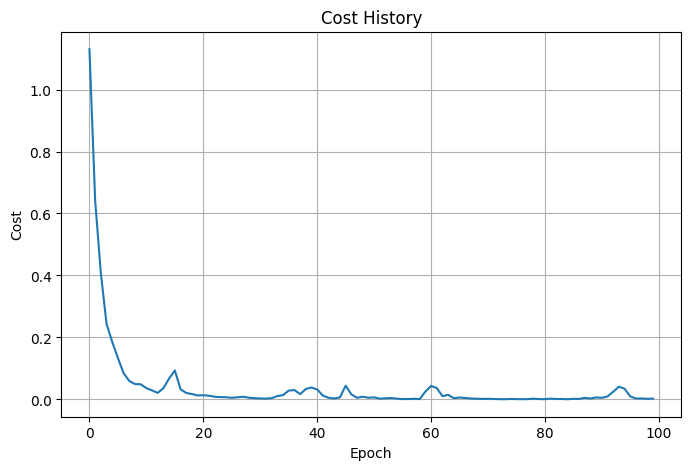

In [21]:
# Plot Cost History
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title("Cost History")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [22]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

train_acc = evaluate_accuracy(model, train_loader)
test_acc = evaluate_accuracy(model, test_loader)

print(f"Train accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Train accuracy: 100.00%
Test accuracy: 95.83%


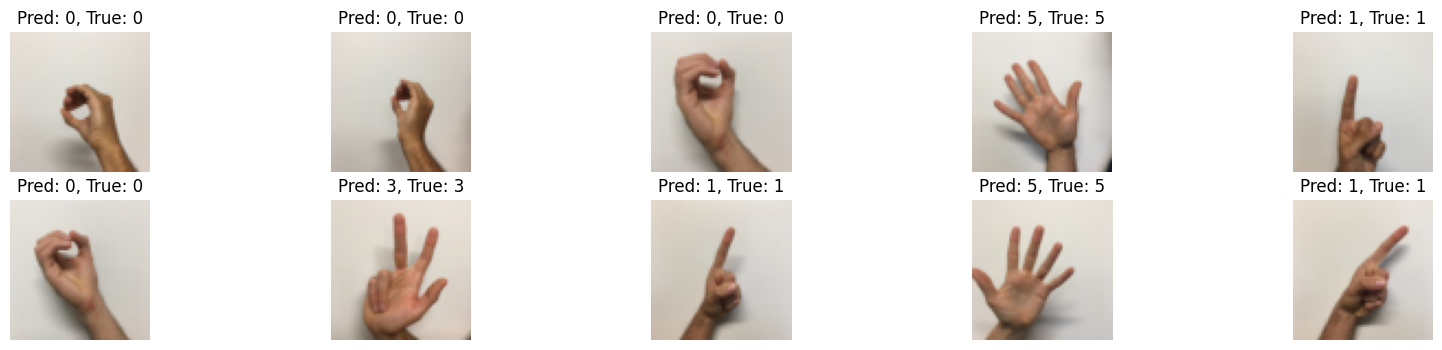

In [23]:
# Show sample predictions
def show_images(loader, model, num_images=10):
    model.eval()
    dataiter = iter(loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)
    
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    # Move to CPU for plotting
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()
    
    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        ax = plt.subplot(2, num_images//2, i + 1)
        # Transpose image back to (H, W, C) for display
        img = np.transpose(images[i], (1, 2, 0))
        plt.imshow(img)
        ax.set_title(f"Pred: {preds[i]}, True: {labels[i]}")
        plt.axis('off')
    plt.show()

show_images(test_loader, model, num_images=10)

In [24]:
# 转换png to np.ndarray
def png_to_array(png_path, target_size=(64, 64), normalize=True):
    """
    将 PNG 图片文件转换为 CNN 模型需要的 numpy 数组格式
    
    参数:
        png_path: PNG 图片文件路径
        target_size: 目标图片尺寸 (height, width)，默认 (64, 64)
        normalize: 是否归一化到 [0, 1]，默认 True
    
    返回:
        img_array: numpy 数组，形状为 (1, C, H, W)，即 (1, 3, 64, 64)
    """
    from PIL import Image
    
    # 1. 读取 PNG 图片
    img = Image.open(png_path)
    
    # 2. 转换为 RGB 格式（如果是 RGBA 或其他格式）
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # 3. 调整图片大小到目标尺寸
    img = img.resize(target_size)
    
    # 4. 转换为 numpy 数组 (H, W, C) = (64, 64, 3)
    img_array = np.array(img, dtype=np.float32)
    
    # 5. 归一化到 [0, 1]（如果启用）
    if normalize:
        img_array = img_array
    
    # 6. 转换为 CNN 需要的格式 (N, C, H, W) = (1, 3, 64, 64)
    img_array = img_array.transpose(2, 0, 1)  # (H, W, C) -> (C, H, W)
    img_array = img_array[np.newaxis, :]  # (C, H, W) -> (1, C, H, W)
    
    return img_array

# 使用示例:
# img_array = png_to_array('path/to/image.png')
# prediction = cnn.predict(img_array)
# probability = cnn.forward(img_array)

(120,)


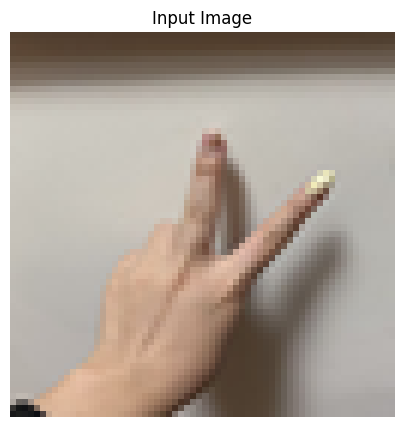

TypeError: pad(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [25]:
picture_path="./pictures/2_1.png" 
p_test = png_to_array(picture_path)
print(Y_test_orig[0].shape)
# p_test = A_test[1].reshape(1,*A_test[0].shape)
# p_test = np.random.randn(1,3,64,64)

# 显示图片：将 (1, C, H, W) 格式转换为 (H, W, C) 格式
img_to_show = p_test[0].transpose(1, 2, 0)/255.0 # (C, H, W) -> (H, W, C)
plt.figure(figsize=(5, 5))
plt.imshow(img_to_show)
plt.axis('off')
plt.title('Input Image')
plt.show()

p_pred = model(p_test/255.0)
p_pred
